# Классификация пассажиров автобуса (входящие / выходящие)

**Цель:** добиться точности работы модели выше 90% на проверочной выборке.

## Загрузка данных

In [ ]:
# загрузка библиотек

# Методы для отрисовки изображений
from PIL import Image

# Для отрисовки графиков
import matplotlib.pyplot as plt

# Для генерации случайных чисел
import random

# Библиотека работы с массивами
import numpy as np

# Для работы с файлами
import os

# Импортируем модуль для загрузки данных
import gdown

# Для разделения выборок
from sklearn.model_selection import train_test_split

# Для автоматического расчёта весов классов
from sklearn.utils.class_weight import compute_class_weight

# Матрица ошибок и отчёт классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Генератор аугментированных изображений
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Для создания сети
from tensorflow.keras.models import Sequential

# Для создания слоёв
from tensorflow.keras.layers import (Dense, Conv2D, MaxPooling2D, Flatten,
                                     Dropout, BatchNormalization, LeakyReLU,
                                     GlobalAveragePooling2D)

# Для работы с изображениями
from tensorflow.keras.preprocessing import image

# Колбеки
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Преобразование меток в One-Hot
from tensorflow.keras.utils import to_categorical

# Оптимизатор
from tensorflow.keras.optimizers import Adam

In [ ]:
# Загрузка датасета (.zip-архив)
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l4/bus.zip', None, quiet=True)

# Распаковка архива
!unzip -q "bus.zip" -d /content/bus

# Папка с папками картинок, рассортированных по категориям
IMAGE_PATH = '/content/bus'
os.listdir(IMAGE_PATH)

['Входящий', 'Выходящий']

In [ ]:
# Определение списка имён классов
CLASS_LIST = sorted(os.listdir(IMAGE_PATH))

# Определение количества классов
CLASS_COUNT = len(CLASS_LIST)

print(f'Количество классов: {CLASS_COUNT}, метки классов: {CLASS_LIST}')

Количество классов: 2, метки классов: ['Входящий', 'Выходящий']


## Гиперпараметры

In [ ]:
# Параметры разделения выборок
TEST_SPLIT          = 0.1                   # Доля тестовых данных в общем наборе
VAL_SPLIT           = 0.2                   # Доля проверочной выборки в обучающем наборе

# Параметры изображения (соотношение 2:1 — соответствует фигуре человека в полный рост)
IMG_WIDTH           = 64                    # Ширина изображения для нейросети
IMG_HEIGHT          = 128                   # Высота изображения для нейросети
IMG_CHANNELS        = 3                     # RGB

# Параметры аугментации
ROTATION_RANGE      = 15                    # Пределы поворота в градусах
WIDTH_SHIFT_RANGE   = 0.1                   # Пределы сдвига по горизонтали
HEIGHT_SHIFT_RANGE  = 0.1                   # Пределы сдвига по вертикали
ZOOM_RANGE          = 0.1                   # Пределы увеличения/уменьшения
BRIGHTNESS_RANGE    = (0.7, 1.3)            # Пределы изменения яркости
HORIZONTAL_FLIP     = False                 # Без флипа: направление движения важно

# Параметры обучения
EPOCHS              = 50                    # Максимальное число эпох (EarlyStopping остановит раньше)
BATCH_SIZE          = 32                    # Размер батча
OPTIMIZER           = Adam(learning_rate=0.0005)  # Оптимизатор

## Загрузка изображений

In [ ]:
images = []
labels = []

for i, class_name in enumerate(CLASS_LIST):
    class_path = os.path.join(IMAGE_PATH, class_name)
    for img_name in os.listdir(class_path):
        img = image.load_img(os.path.join(class_path, img_name),
                             target_size=(IMG_HEIGHT, IMG_WIDTH))
        images.append(image.img_to_array(img))
        labels.append(i)

images = np.array(images, dtype='float32')
labels = np.array(labels)

print(f'Всего изображений: {len(images)}')
print(f'Форма массива: {images.shape}')
print(f'Распределение классов: {np.bincount(labels)}')

Всего изображений: 9081
Форма массива: (9081, 128, 64, 3)
Распределение классов: [6485 2596]


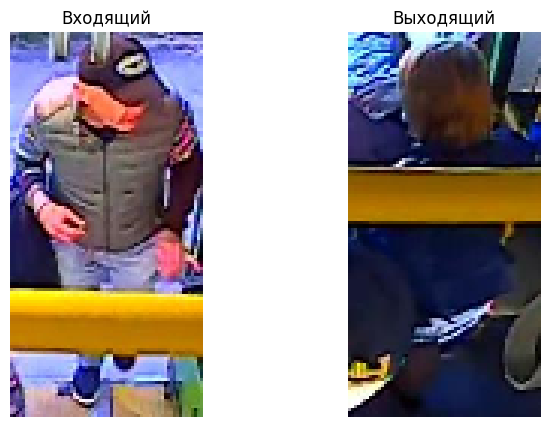

In [ ]:
# Просмотр по одному изображению из каждого класса
fig, axs = plt.subplots(1, CLASS_COUNT, figsize=(8, 5))
for i in range(CLASS_COUNT):
    idx = np.where(labels == i)[0][0]
    axs[i].imshow(images[idx].astype('uint8'))
    axs[i].set_title(CLASS_LIST[i])
    axs[i].axis('off')
plt.show()

## Разделение на train / val / test со стратификацией

In [ ]:
# Сначала отделяем тестовую выборку (10% от всех данных)
x_train_full, x_test, y_train_full, y_test = train_test_split(
    images, labels,
    test_size=TEST_SPLIT,
    random_state=42,
    stratify=labels
)

# Затем делим оставшиеся данные на обучающую и проверочную (20% от обучающего набора)
x_train, x_val, y_train_raw, y_val_raw = train_test_split(
    x_train_full, y_train_full,
    test_size=VAL_SPLIT,
    random_state=42,
    stratify=y_train_full
)

# Преобразуем метки в One-Hot Encoding
y_train = to_categorical(y_train_raw, num_classes=CLASS_COUNT)
y_val = to_categorical(y_val_raw, num_classes=CLASS_COUNT)
y_test_ohe = to_categorical(y_test, num_classes=CLASS_COUNT)

print(f'Обучающий набор:    {x_train.shape}, метки: {y_train.shape}')
print(f'Проверочный набор:  {x_val.shape}, метки: {y_val.shape}')
print(f'Тестовый набор:     {x_test.shape}, метки: {y_test_ohe.shape}')

Обучающий набор:    (6537, 128, 64, 3), метки: (6537, 2)
Проверочный набор:  (1635, 128, 64, 3), метки: (1635, 2)
Тестовый набор:     (909, 128, 64, 3), метки: (909, 2)


In [ ]:
# Проверка распределения классов в каждой выборке
def print_balance(y_data, set_name):
    if len(y_data.shape) > 1:
        y_data = np.argmax(y_data, axis=1)
    unique, counts = np.unique(y_data, return_counts=True)
    print(f'Распределение в {set_name}:')
    for i, count in enumerate(counts):
        print(f'  Класс {CLASS_LIST[i]}: {count} ({count/len(y_data)*100:.1f}%)')

print_balance(y_train, 'обучающем наборе')
print_balance(y_val, 'проверочном наборе')
print_balance(y_test_ohe, 'тестовом наборе')

Распределение в обучающем наборе:
  Класс Входящий: 4668 (71.4%)
  Класс Выходящий: 1869 (28.6%)
Распределение в проверочном наборе:
  Класс Входящий: 1168 (71.4%)
  Класс Выходящий: 467 (28.6%)
Распределение в тестовом наборе:
  Класс Входящий: 649 (71.4%)
  Класс Выходящий: 260 (28.6%)


In [ ]:
# Автоматический расчёт весов классов для компенсации дисбаланса
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_raw),
    y=y_train_raw
)
class_weight_dict = dict(enumerate(class_weights))
print(f'Веса классов: {class_weight_dict}')

Веса классов: {0: np.float64(0.7001928020565553), 1: np.float64(1.7487961476725522)}


## Аугментация изображений

In [ ]:
# Генератор для обучающей выборки — нормализация + аугментация
train_datagen = ImageDataGenerator(
    rescale=1./255.,
    rotation_range=ROTATION_RANGE,
    width_shift_range=WIDTH_SHIFT_RANGE,
    height_shift_range=HEIGHT_SHIFT_RANGE,
    zoom_range=ZOOM_RANGE,
    brightness_range=BRIGHTNESS_RANGE,
    horizontal_flip=HORIZONTAL_FLIP,
)

# Для проверочной и тестовой выборок только нормализация
val_datagen = ImageDataGenerator(rescale=1./255.)
test_datagen = ImageDataGenerator(rescale=1./255.)

# Создание генераторов
train_generator = train_datagen.flow(x_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
validation_generator = val_datagen.flow(x_val, y_val, batch_size=BATCH_SIZE, shuffle=False)
test_generator = test_datagen.flow(x_test, y_test_ohe, batch_size=BATCH_SIZE, shuffle=False)

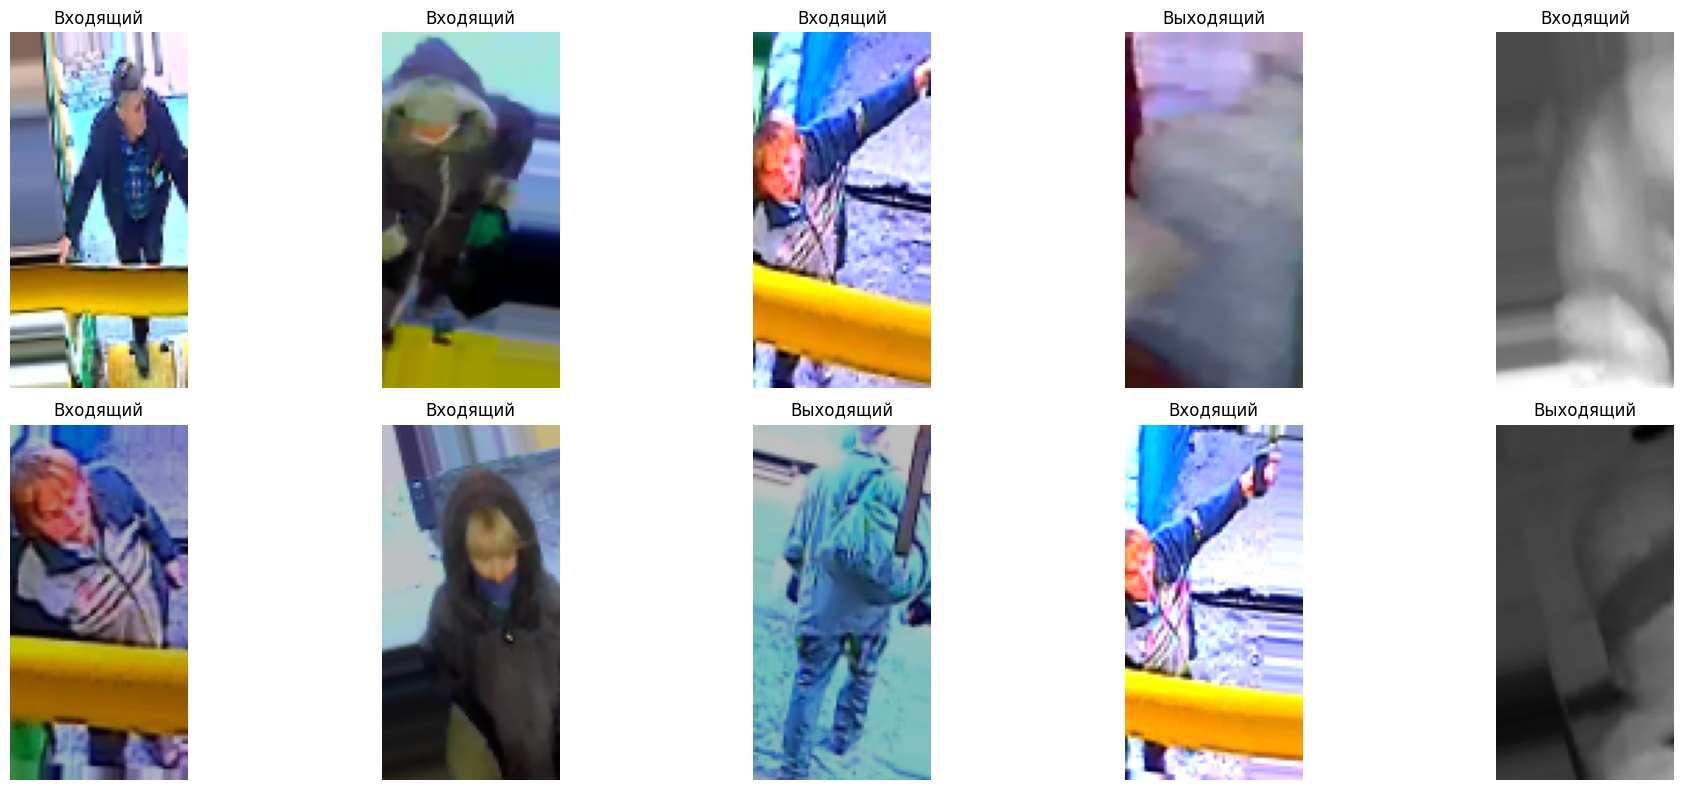

In [ ]:
# Проверка работы аугментации
def show_batch(batch, img_range=range(10), figsize=(20, 8), columns=5):
    num_images = len(img_range)
    rows = (num_images + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=figsize)
    axes = axes.flatten()
    for i, img_idx in enumerate(img_range):
        img = batch[0][img_idx]
        axes[i].imshow(np.clip(img, 0, 1))
        class_label_idx = np.argmax(batch[1][img_idx])
        axes[i].set_title(CLASS_LIST[class_label_idx])
        axes[i].axis('off')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

example_batch = next(train_generator)
show_batch(example_batch, img_range=range(10), columns=5)

## Создание модели

Архитектура использует паттерн VGG: парные свёртки 3×3 в каждом блоке. Две свёртки 3×3 эквивалентны одной 5×5 по рецептивному полю, но требуют меньше параметров и добавляют дополнительную нелинейность.

In [ ]:
cnn_model = Sequential([
    # ========== Блок 1: 32 фильтра ==========
    Conv2D(32, (3, 3), padding='same',
           input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Conv2D(32, (3, 3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # ========== Блок 2: 64 фильтра ==========
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    # ========== Блок 3: 128 фильтров ==========
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),

    # ========== Полносвязная часть ==========
    GlobalAveragePooling2D(),  # резко сокращает параметры по сравнению с Flatten

    Dense(128),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),

    Dense(CLASS_COUNT, activation='softmax')
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 64, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 64, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128, 64, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 64, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 64, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128, 64, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 64, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 64, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 32, 16, 128)    │             

 Total params: 306,082 (1.17 MB)

 Trainable params: 304,930 (1.16 MB)

 Non-trainable params: 1,152 (4.50 KB)

## Обучение модели

In [ ]:
# Компиляция модели
cnn_model.compile(
    optimizer=OPTIMIZER,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Колбеки
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

# Обучение
history = cnn_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    class_weight=class_weight_dict,
    callbacks=[early_stop, lr_reducer],
    verbose=1
)

Epoch 1/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 52s 175ms/step - accuracy: 0.6101 - loss: 0.7554 - val_accuracy: 0.5896 - val_loss: 0.6389 - learning_rate: 5.0000e-04
Epoch 2/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.6885 - loss: 0.6035 - val_accuracy: 0.7486 - val_loss: 0.4540 - learning_rate: 5.0000e-04
Epoch 3/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 22s 109ms/step - accuracy: 0.7271 - loss: 0.5378 - val_accuracy: 0.8177 - val_loss: 0.3925 - learning_rate: 5.0000e-04
Epoch 4/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 22s 109ms/step - accuracy: 0.7326 - loss: 0.5113 - val_accuracy: 0.8239 - val_loss: 0.3605 - learning_rate: 5.0000e-04
Epoch 5/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.7669 - loss: 0.4606 - val_accuracy: 0.8098 - val_loss: 0.9688 - learning_rate: 5.0000e-04
Epoch 6/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.7733 - loss: 0.4461 - val_accuracy: 0.8294 - val_loss: 0.3870 - learning_rate: 5.0000e-04
Epoch 7/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 102m

## График обучения

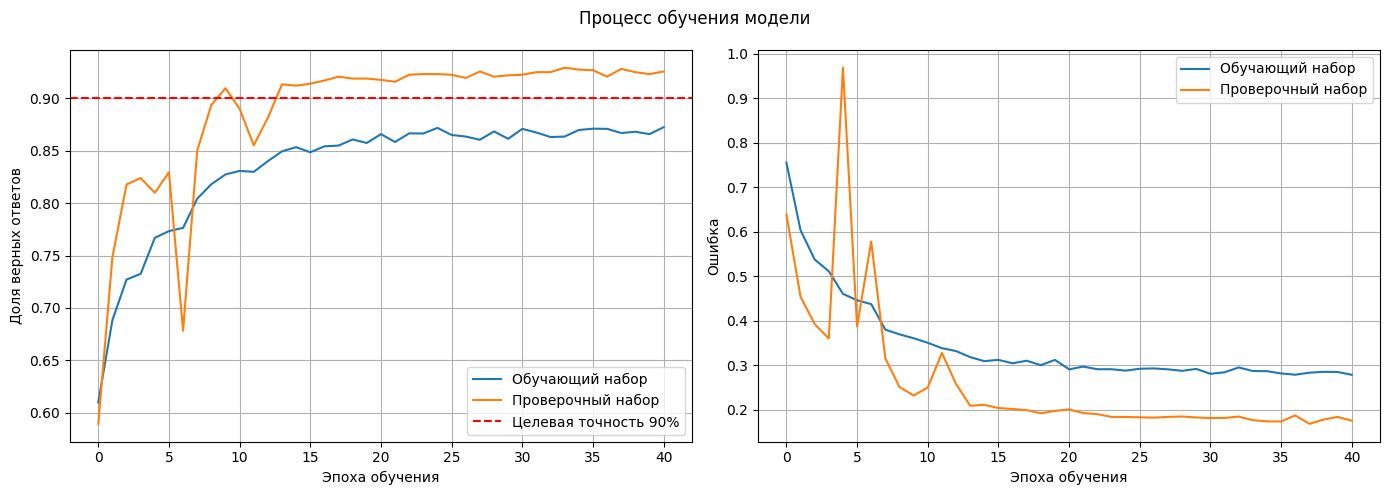


Лучшая точность на проверочной выборке: 0.9291 (92.91%)
Цель достигнута! Точность выше 90%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Процесс обучения модели')

ax1.plot(history.history['accuracy'], label='Обучающий набор')
ax1.plot(history.history['val_accuracy'], label='Проверочный набор')
ax1.axhline(y=0.9, color='r', linestyle='--', label='Целевая точность 90%')
ax1.set_xlabel('Эпоха обучения')
ax1.set_ylabel('Доля верных ответов')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Обучающий набор')
ax2.plot(history.history['val_loss'], label='Проверочный набор')
ax2.set_xlabel('Эпоха обучения')
ax2.set_ylabel('Ошибка')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

best_val_acc = max(history.history['val_accuracy'])
print(f'\nЛучшая точность на проверочной выборке: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
if best_val_acc > 0.9:
    print('Цель достигнута! Точность выше 90%')
else:
    print('Цель пока не достигнута')

## Оценка на тестовой выборке

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


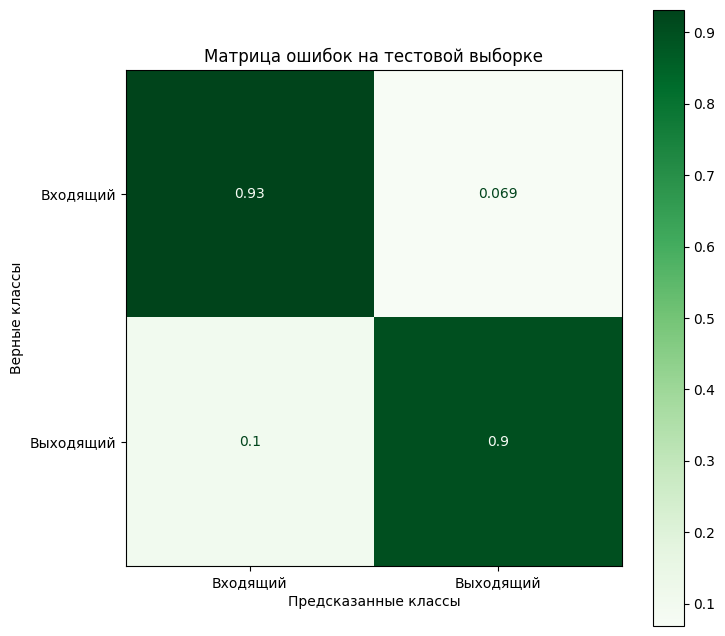


Подробный отчёт по классам:
              precision    recall  f1-score   support

    Входящий       0.96      0.93      0.94       649
   Выходящий       0.84      0.90      0.87       260

    accuracy                           0.92       909
   macro avg       0.90      0.92      0.91       909
weighted avg       0.92      0.92      0.92       909



In [ ]:
# Получаем предсказания на ВСЕЙ тестовой выборке (а не на одном батче)
test_generator.reset()
y_pred = cnn_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test  # исходные метки до OHE

# Матрица ошибок (нормализованная по строкам)
cm = confusion_matrix(y_true, y_pred_classes, normalize='true')
cm = np.round(cm, 3)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LIST)
disp.plot(ax=ax, cmap='Greens', colorbar=True)
plt.title('Матрица ошибок на тестовой выборке')
plt.xlabel('Предсказанные классы')
plt.ylabel('Верные классы')
plt.show()

# Подробный отчёт: precision, recall, F1 по каждому классу
print('\nПодробный отчёт по классам:')
print(classification_report(y_true, y_pred_classes, target_names=CLASS_LIST))

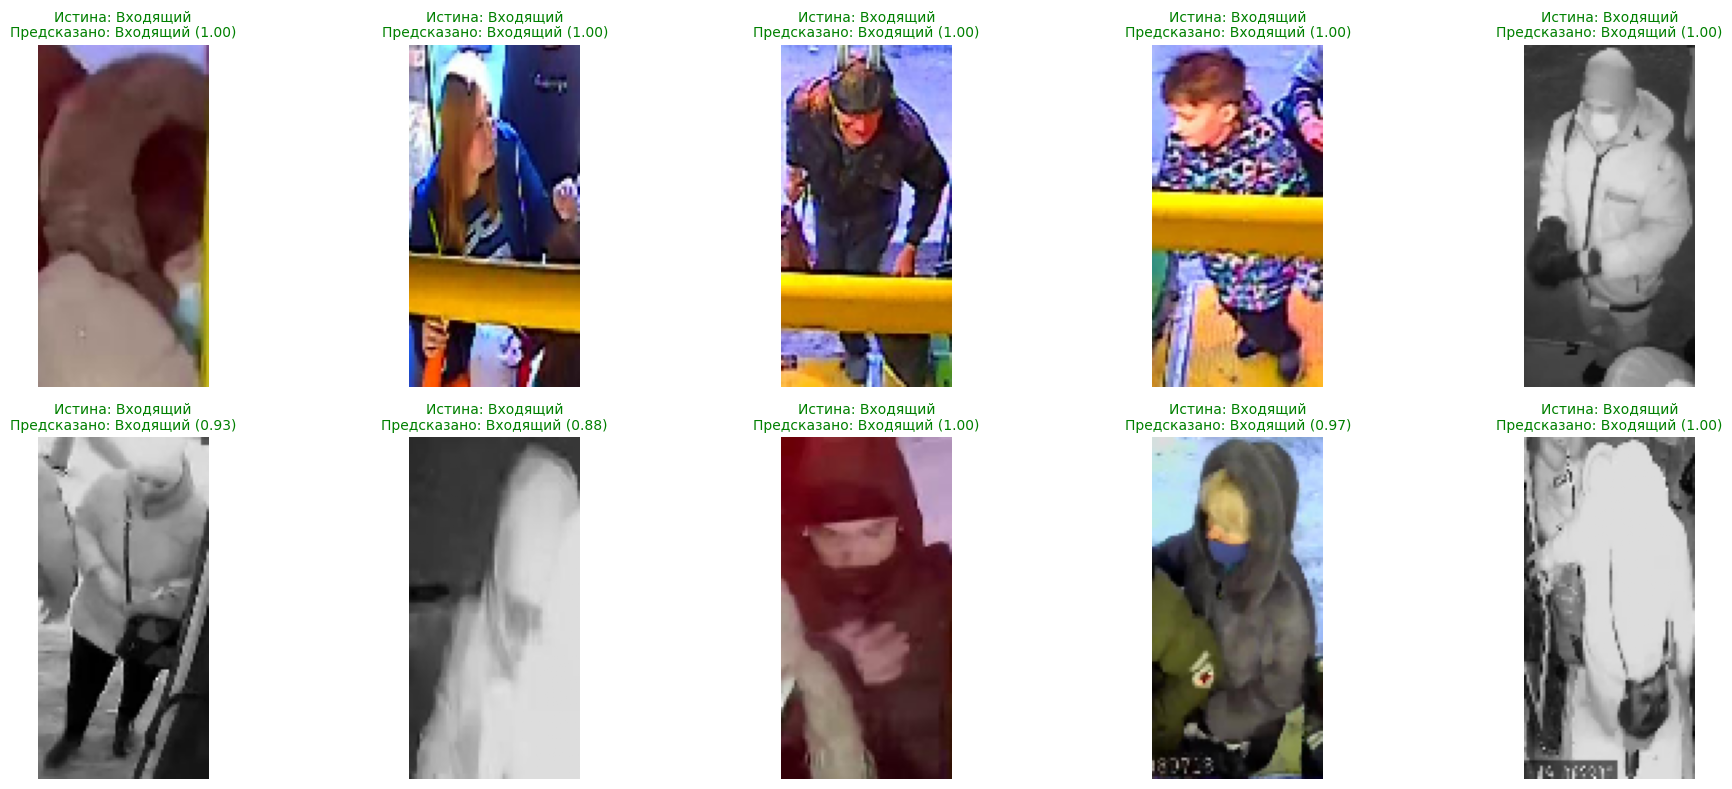

In [ ]:
# Визуальный просмотр предсказаний на случайных примерах
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
axs = axs.flatten()

indices = random.sample(range(len(x_test)), 10)
for i, idx in enumerate(indices):
    img = (x_test[idx] / 255.0).clip(0, 1)
    true_label = CLASS_LIST[y_test[idx]]
    pred_label = CLASS_LIST[y_pred_classes[idx]]
    pred_proba = y_pred[idx][y_pred_classes[idx]]

    color = 'green' if true_label == pred_label else 'red'
    axs[i].imshow(img)
    axs[i].set_title(f'Истина: {true_label}\nПредсказано: {pred_label} ({pred_proba:.2f})',
                     color=color, fontsize=10)
    axs[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Сохранение модели
cnn_model.save('cnn_model_pro_tf.keras')
print('Модель сохранена в cnn_model_pro_tf.keras')

Модель сохранена в cnn_model_pro_tf.keras
